# STEP 3 전처리 Colab 노트북 (서울시 주요상권 생활인구)
- 원본: TOTL / NAOR / STPRD_FRNR / LOPRD_FRNR 4개 CSV
- 출력: `merged_features_v1.csv`

⚠️ **주의**: 파일 구분자가 `|` 인 데이터이므로 `sep='|'` 로 읽어야 합니다.

## 0. 라이브러리 & 파일 경로 설정

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ====== 파일 경로를 팀 폴더 구조에 맞게 수정하세요 ======
PATH_TOTL  = "/content/drive/MyDrive/서울시상권/전체인구(TOTL).csv"   # 예: "data/raw/TOTL.csv"
PATH_NAOR  = "/content/drive/MyDrive/서울시상권/내국인(NAOR).csv"
PATH_STPRD = "/content/drive/MyDrive/서울시상권/단기외국인(STPRD_FRNR).csv"
PATH_LOPRD = "/content/drive/MyDrive/서울시상권/장기외국인(LOPRD_FRNR).csv"

# 결과 저장 경로
OUT_PATH = "/content/drive/MyDrive/서울시상권/merged_features_v1.csv"


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. 데이터 로딩

In [25]:
totl  = pd.read_csv(PATH_TOTL,  sep="|")
naor  = pd.read_csv(PATH_NAOR,  sep="|")
stprd = pd.read_csv(PATH_STPRD, sep="|")
loprd = pd.read_csv(PATH_LOPRD, sep="|")

print("TOTL :", totl.shape)
print("NAOR :", naor.shape)
print("STPRD:", stprd.shape)
print("LOPRD:", loprd.shape)

display(totl.head())


TOTL : (172, 59)
NAOR : (172, 59)
STPRD: (172, 59)
LOPRD: (172, 59)


,TRDAR_NO,TRDAR_NM,SIGNGU_CD,SIGNGU_NM,GRFA_SM,RSDNTL_BULD_GRFA,RSDNTL_BULD_EXCL_GRFA,MOAV_TOTL_LVLH_POPNO,ZERO_TIZN_TOTL_LVLH_POPNO,ONE_TIZN_TOTL_LVLH_POPNO,...,SXTN_TIZN_TOTL_VST_POPNO,SVNTN_TIZN_TOTL_VST_POPNO,EGHTN_TIZN_TOTL_VST_POPNO,NNTN_TIZN_TOTL_VST_POPNO,TNT_TIZN_TOTL_VST_POPNO,TNONE_TIZN_TOTL_VST_POPNO,TNTT_TIZN_TOTL_VST_POPNO,TNTTH_TIZN_TOTL_VST_POPNO,TRDAR_CRDNT_CONT,DATA_STRD_YM
0,10000,목동역1번 출구,11470,양천구,207580.66,64851.08,142729.58,5257.94,5067.98,5528.96,...,4037.64,4043.17,3952.82,3923.01,3925.48,3880.29,3725.89,3558.16,"POLYGON ((126.858956602584 37.5264695116541, 1...",202510
1,10001,까치산역2번 출구,11500,강서구,128728.71,69566.61,59162.10,13935.64,13764.03,13338.58,...,9297.83,9536.26,9904.00,10060.83,9971.98,10102.78,10166.51,9060.50,"POLYGON ((126.846003564731 37.5336081483754, 1...",202510
2,10002,서울화곡4동우체국,11500,강서구,95733.53,37339.88,58393.65,1012.56,977.88,973.22,...,696.71,712.33,721.88,742.61,724.66,707.09,698.15,677.44,"POLYGON ((126.858333747392 37.5326311955793, 1...",202510
3,10003,우장산역4번 출구,11500,강서구,82426.18,24010.56,58415.62,1227.44,1053.00,1057.95,...,958.79,1008.31,1063.34,1060.91,1019.75,1008.99,995.57,754.14,"POLYGON ((126.835441067063 37.5470125549428, 1...",202510
4,10004,서울화곡본동우편취급국,11500,강서구,119223.18,13447.84,105775.34,2628.53,2962.14,2826.20,...,2278.20,2335.95,2369.17,2476.99,2507.92,2493.97,2468.69,2819.03,"POLYGON ((126.85224837624 37.5545152247243, 12...",202510


## 2. 기본 정합성 검사 (컬럼/키/중복)

In [26]:
# 2-1) 컬럼 동일성 확인
same_cols = (
    list(totl.columns) == list(naor.columns) ==
    list(stprd.columns) == list(loprd.columns)
)
print("4개 파일 컬럼 완전 동일 여부:", same_cols)
if not same_cols:
    print("TOTL-NAOR diff:", set(totl.columns) ^ set(naor.columns))
    print("TOTL-STPRD diff:", set(totl.columns) ^ set(stprd.columns))
    print("TOTL-LOPRD diff:", set(totl.columns) ^ set(loprd.columns))

# 2-2) 키 컬럼 존재 확인
required_keys = ["TRDAR_NO", "DATA_STRD_YM"]
for k in required_keys:
    print(k, "in TOTL?", k in totl.columns)

# 2-3) 키 중복(뻥튀기) 여부 확인
def check_key_uniqueness(df, name):
    dup = df.duplicated(subset=["TRDAR_NO","DATA_STRD_YM"]).sum()
    print(f"[{name}] key 중복 행 수:", dup)

check_key_uniqueness(totl, "TOTL")
check_key_uniqueness(naor, "NAOR")
check_key_uniqueness(stprd, "STPRD")
check_key_uniqueness(loprd, "LOPRD")


4개 파일 컬럼 완전 동일 여부: False
TOTL-NAOR diff: {'FOUR_TIZN_TOTL_LVLH_POPNO', 'EIGHT_TIZN_NAOR_VST_POPNO', 'THIRTEEN_TIZN_TOTL_VST_POPNO', 'ELEVEN_TIZN_TOTL_VST_POPNO', 'TNTT_TIZN_TOTL_LVLH_POPNO', 'SVNTN_TIZN_TOTL_LVLH_POPNO', 'SIX_TIZN_TOTL_LVLH_POPNO', 'SIX_TIZN_TOTL_VST_POPNO', 'ONE_TIZN_TOTL_VST_POPNO', 'TWO_TIZN_TOTL_VST_POPNO', 'TNT_TIZN_NAOR_LVLH_POPNO', 'ELEVEN_TIZN_NAOR_VST_POPNO', 'TEN_TIZN_TOTL_LVLH_POPNO', 'TEN_TIZN_NAOR_LVLH_POPNO', 'NINE_TIZN_TOTL_LVLH_POPNO', 'NNTN_TIZN_NAOR_LVLH_POPNO', 'SXTN_TIZN_TOTL_LVLH_POPNO', 'SXTN_TIZN_NAOR_VST_POPNO', 'TNONE_TIZN_NAOR_LVLH_POPNO', 'NNTN_TIZN_NAOR_VST_POPNO', 'NINE_TIZN_TOTL_VST_POPNO', 'THREE_TIZN_NAOR_LVLH_POPNO', 'EIGHT_TIZN_TOTL_LVLH_POPNO', 'EGHTN_TIZN_NAOR_VST_POPNO', 'SIX_TIZN_NAOR_VST_POPNO', 'SEVEN_TIZN_TOTL_LVLH_POPNO', 'NINE_TIZN_NAOR_LVLH_POPNO', 'TWO_TIZN_NAOR_VST_POPNO', 'TEN_TIZN_NAOR_VST_POPNO', 'ONE_TIZN_NAOR_VST_POPNO', 'THREE_TIZN_TOTL_LVLH_POPNO', 'FFTN_TIZN_NAOR_LVLH_POPNO', 'TWO_TIZN_TOTL_LVLH_POPNO', 'EGHTN_TIZN_

## 3. 결측치 확인 (4개 파일 모두)

In [27]:
def missing_report(df, name):
    total_missing = int(df.isna().sum().sum())
    print(f"[{name}] 총 결측치:", total_missing)
    if total_missing > 0:
        miss = df.isna().sum().sort_values(ascending=False)
        display(miss[miss > 0].head(20))

missing_report(totl, "TOTL")
missing_report(naor, "NAOR")
missing_report(stprd, "STPRD")
missing_report(loprd, "LOPRD")


[TOTL] 총 결측치: 0
[NAOR] 총 결측치: 0
[STPRD] 총 결측치: 0
[LOPRD] 총 결측치: 0


## 4. 이상치/분포 점검 (면적/인구 음수/시간대 컬럼)

,0


GRFA_SM = 0 개수: 0


,GRFA_SM
count,1.720000e+02
mean,4.008493e+05
std,1.303914e+06
min,1.291349e+04
25%,1.169765e+05
50%,2.096819e+05
75%,3.840556e+05
max,1.692940e+07


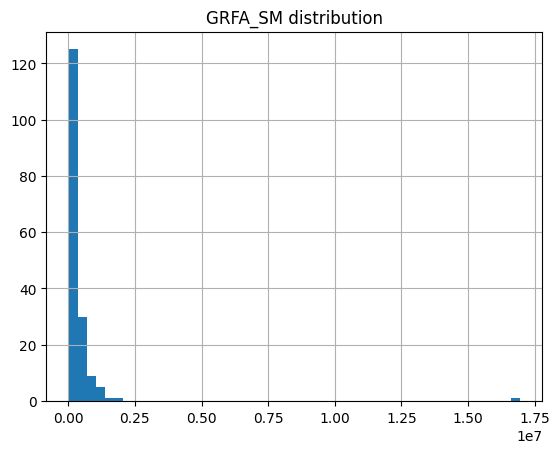

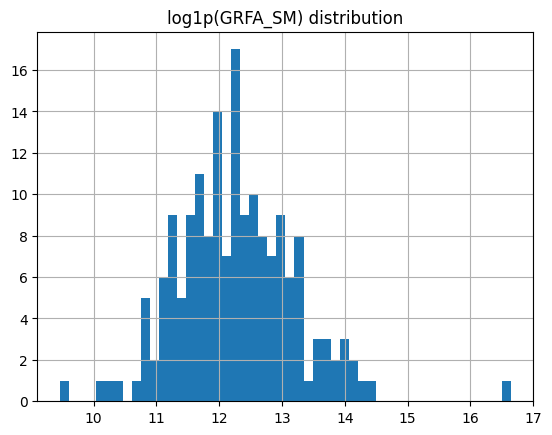

생활인구 시간대 컬럼 수: 24
방문인구 시간대 컬럼 수: 24


,ZERO_TIZN_TOTL_LVLH_POPNO,ONE_TIZN_TOTL_LVLH_POPNO,TWO_TIZN_TOTL_LVLH_POPNO,THREE_TIZN_TOTL_LVLH_POPNO,FOUR_TIZN_TOTL_LVLH_POPNO,FIVE_TIZN_TOTL_LVLH_POPNO,SIX_TIZN_TOTL_LVLH_POPNO,SEVEN_TIZN_TOTL_LVLH_POPNO,EIGHT_TIZN_TOTL_LVLH_POPNO,NINE_TIZN_TOTL_LVLH_POPNO,...,FOURTEEN_TIZN_TOTL_LVLH_POPNO,FFTN_TIZN_TOTL_LVLH_POPNO,SXTN_TIZN_TOTL_LVLH_POPNO,SVNTN_TIZN_TOTL_LVLH_POPNO,EGHTN_TIZN_TOTL_LVLH_POPNO,NNTN_TIZN_TOTL_LVLH_POPNO,TNT_TIZN_TOTL_LVLH_POPNO,TNONE_TIZN_TOTL_LVLH_POPNO,TNTT_TIZN_TOTL_LVLH_POPNO,TNTTH_TIZN_TOTL_LVLH_POPNO
min,111.78,105.98,107.34,108.78,116.72,146.51,211.82,443.11,584.15,643.73,...,778.98,817.89,843.70,849.60,722.73,496.65,399.29,322.38,261.18,137.21
max,26982.78,25717.41,23844.74,22585.96,21390.98,19522.38,18628.77,25060.80,34489.96,40800.96,...,49716.73,49576.79,49316.92,49182.12,48809.33,48458.51,45916.74,41311.74,35215.95,30520.66


,ZERO_TIZN_TOTL_VST_POPNO,ONE_TIZN_TOTL_VST_POPNO,TWO_TIZN_TOTL_VST_POPNO,THREE_TIZN_TOTL_VST_POPNO,FOUR_TIZN_TOTL_VST_POPNO,FIVE_TIZN_TOTL_VST_POPNO,SIX_TIZN_TOTL_VST_POPNO,SEVEN_TIZN_TOTL_VST_POPNO,EIGHT_TIZN_TOTL_VST_POPNO,NINE_TIZN_TOTL_VST_POPNO,...,FOURTEEN_TIZN_TOTL_VST_POPNO,FFTN_TIZN_TOTL_VST_POPNO,SXTN_TIZN_TOTL_VST_POPNO,SVNTN_TIZN_TOTL_VST_POPNO,EGHTN_TIZN_TOTL_VST_POPNO,NNTN_TIZN_TOTL_VST_POPNO,TNT_TIZN_TOTL_VST_POPNO,TNONE_TIZN_TOTL_VST_POPNO,TNTT_TIZN_TOTL_VST_POPNO,TNTTH_TIZN_TOTL_VST_POPNO
min,111.60,105.81,107.17,108.60,116.53,146.28,211.48,431.26,466.50,498.10,...,556.67,577.26,597.08,611.35,601.36,495.85,398.65,321.87,260.76,136.99
max,23126.26,22000.86,20346.56,19218.57,18137.88,16447.16,16332.58,21596.50,30529.89,36417.54,...,44375.40,44168.63,43762.88,43409.44,41938.28,41685.35,39556.99,35632.72,30314.31,26303.35


sum_vst > sum_lvlh 인 상권 개수: 0


,TRDAR_NO,TRDAR_NM,sum_lvlh,sum_vst


In [28]:
# 4-1) 숫자형 컬럼에서 음수값 점검
num_cols = totl.select_dtypes(include=[np.number]).columns
neg_counts = (totl[num_cols] < 0).sum().sort_values(ascending=False)
display(neg_counts[neg_counts > 0].head(20))

# 4-2) GRFA_SM(상권 면적) 분포
print("GRFA_SM = 0 개수:", int((totl["GRFA_SM"] == 0).sum()))
display(totl["GRFA_SM"].describe())

plt.figure()
totl["GRFA_SM"].hist(bins=50)
plt.title("GRFA_SM distribution")
plt.show()

plt.figure()
np.log1p(totl["GRFA_SM"]).hist(bins=50)
plt.title("log1p(GRFA_SM) distribution")
plt.show()

# 4-3) 시간대 컬럼 자동 추출(전체 생활인구/방문인구)
lv_cols = [c for c in totl.columns if "_TOTL_LVLH_POPNO" in c and "MOAV" not in c]
vs_cols = [c for c in totl.columns if "_TOTL_VST_POPNO"  in c and "MOAV" not in c]
print("생활인구 시간대 컬럼 수:", len(lv_cols))
print("방문인구 시간대 컬럼 수:", len(vs_cols))

if len(lv_cols) > 0:
    display(totl[lv_cols].describe().loc[["min","max"]])
if len(vs_cols) > 0:
    display(totl[vs_cols].describe().loc[["min","max"]])

# 참고용: 방문인구 합이 생활인구 합보다 큰 상권 후보(원인 분석은 Step4에서)
if len(lv_cols) > 0 and len(vs_cols) > 0:
    tmp = totl.copy()
    tmp["sum_lvlh"] = tmp[lv_cols].sum(axis=1)
    tmp["sum_vst"]  = tmp[vs_cols].sum(axis=1)
    flag = tmp[tmp["sum_vst"] > tmp["sum_lvlh"]][["TRDAR_NO","TRDAR_NM","sum_lvlh","sum_vst"]]
    print("sum_vst > sum_lvlh 인 상권 개수:", len(flag))
    display(flag.head(10))


## 5. 병합(Merge) — 키(TRDAR_NO, DATA_STRD_YM) 기준으로 옆으로 붙이기

In [29]:
# 병합에 필요한 최소 컬럼만 선택 (중복 컬럼 충돌 방지)
naor_sel  = naor[["TRDAR_NO","DATA_STRD_YM","MOAV_NAOR_LVLH_POPNO"]]
stprd_sel = stprd[["TRDAR_NO","DATA_STRD_YM","MOAV_STPRD_FRNR_LVLH_POPNO"]]
loprd_sel = loprd[["TRDAR_NO","DATA_STRD_YM","MOAV_LOPRD_FRNR_LVLH_POPNO"]]

df = totl.merge(naor_sel,  on=["TRDAR_NO","DATA_STRD_YM"], how="left")
df = df.merge(stprd_sel, on=["TRDAR_NO","DATA_STRD_YM"], how="left")
df = df.merge(loprd_sel, on=["TRDAR_NO","DATA_STRD_YM"], how="left")

print("병합 후 shape:", df.shape)
display(df.head())


병합 후 shape: (172, 62)


,TRDAR_NO,TRDAR_NM,SIGNGU_CD,SIGNGU_NM,GRFA_SM,RSDNTL_BULD_GRFA,RSDNTL_BULD_EXCL_GRFA,MOAV_TOTL_LVLH_POPNO,ZERO_TIZN_TOTL_LVLH_POPNO,ONE_TIZN_TOTL_LVLH_POPNO,...,NNTN_TIZN_TOTL_VST_POPNO,TNT_TIZN_TOTL_VST_POPNO,TNONE_TIZN_TOTL_VST_POPNO,TNTT_TIZN_TOTL_VST_POPNO,TNTTH_TIZN_TOTL_VST_POPNO,TRDAR_CRDNT_CONT,DATA_STRD_YM,MOAV_NAOR_LVLH_POPNO,MOAV_STPRD_FRNR_LVLH_POPNO,MOAV_LOPRD_FRNR_LVLH_POPNO
0,10000,목동역1번 출구,11470,양천구,207580.66,64851.08,142729.58,5257.94,5067.98,5528.96,...,3923.01,3925.48,3880.29,3725.89,3558.16,"POLYGON ((126.858956602584 37.5264695116541, 1...",202510,5125.80,12.32,121.20
1,10001,까치산역2번 출구,11500,강서구,128728.71,69566.61,59162.10,13935.64,13764.03,13338.58,...,10060.83,9971.98,10102.78,10166.51,9060.50,"POLYGON ((126.846003564731 37.5336081483754, 1...",202510,13401.64,182.55,353.30
2,10002,서울화곡4동우체국,11500,강서구,95733.53,37339.88,58393.65,1012.56,977.88,973.22,...,742.61,724.66,707.09,698.15,677.44,"POLYGON ((126.858333747392 37.5326311955793, 1...",202510,981.59,2.15,30.34
3,10003,우장산역4번 출구,11500,강서구,82426.18,24010.56,58415.62,1227.44,1053.00,1057.95,...,1060.91,1019.75,1008.99,995.57,754.14,"POLYGON ((126.835441067063 37.5470125549428, 1...",202510,1212.81,3.64,11.85
4,10004,서울화곡본동우편취급국,11500,강서구,119223.18,13447.84,105775.34,2628.53,2962.14,2826.20,...,2476.99,2507.92,2493.97,2468.69,2819.03,"POLYGON ((126.85224837624 37.5545152247243, 12...",202510,2526.74,29.53,72.42


### 5-1. 병합 검증 (결측/중복)

In [30]:
merge_cols = ["MOAV_NAOR_LVLH_POPNO","MOAV_STPRD_FRNR_LVLH_POPNO","MOAV_LOPRD_FRNR_LVLH_POPNO"]
display(df[merge_cols].isna().sum())

dup_after = df.duplicated(subset=["TRDAR_NO","DATA_STRD_YM"]).sum()
print("병합 후 key 중복 행 수:", int(dup_after))


,0
MOAV_NAOR_LVLH_POPNO,0
MOAV_STPRD_FRNR_LVLH_POPNO,0
MOAV_LOPRD_FRNR_LVLH_POPNO,0


병합 후 key 중복 행 수: 0


## 6. 파생변수 생성(Feature Engineering) + 검증

In [31]:
# 시간대 생활인구 컬럼(병합 후에도 동일)
time_cols = [c for c in df.columns if "_TOTL_LVLH_POPNO" in c and "MOAV" not in c]

# 1) 피크 시간대(컬럼명)
df["peak_hour_col"] = df[time_cols].idxmax(axis=1) if len(time_cols) > 0 else np.nan

# 2) 주간/야간 비율 (09~17 / 18~23) — time_cols 순서가 0~23시라고 가정
if len(time_cols) == 24:
    day_cols   = time_cols[9:18]
    night_cols = time_cols[18:24]
    total = df[time_cols].sum(axis=1)
    df["day_ratio"]   = df[day_cols].sum(axis=1) / total
    df["night_ratio"] = df[night_cols].sum(axis=1) / total
else:
    df["day_ratio"] = np.nan
    df["night_ratio"] = np.nan

# 3) 외국인 비중
df["foreigner_ratio"] = (
    df["MOAV_STPRD_FRNR_LVLH_POPNO"] + df["MOAV_LOPRD_FRNR_LVLH_POPNO"]
) / df["MOAV_TOTL_LVLH_POPNO"]

# 4) 인구 밀도
df["population_density"] = df["MOAV_TOTL_LVLH_POPNO"] / df["GRFA_SM"]

# 검증
display(df[["day_ratio","night_ratio","foreigner_ratio","population_density"]].describe())
display(df[["peak_hour_col","day_ratio","night_ratio","foreigner_ratio","population_density"]].isna().sum())


,day_ratio,night_ratio,foreigner_ratio,population_density
count,172.000000,172.000000,172.000000,172.000000
mean,0.481386,0.252601,0.076243,0.027273
std,0.085362,0.039589,0.060914,0.040738
min,0.332126,0.148026,0.009245,0.001989
25%,0.414412,0.227740,0.035471,0.015018
50%,0.473065,0.256892,0.058762,0.021606
75%,0.540746,0.279312,0.099940,0.029610
max,0.690396,0.336215,0.418292,0.504425


,0
peak_hour_col,0
day_ratio,0
night_ratio,0
foreigner_ratio,0
population_density,0


## 7. 최종 데이터셋 저장 & 재로딩 확인

In [32]:
# 최종 컬럼 구성(메타 + 월평균 + 시간대(생활인구) + 파생변수)
keep_meta = [
    "TRDAR_NO","TRDAR_NM","SIGNGU_NM","DATA_STRD_YM","GRFA_SM",
    "RSDNTL_BULD_GRFA","RSDNTL_BULD_EXCL_GRFA",
    "MOAV_TOTL_LVLH_POPNO",
    "MOAV_NAOR_LVLH_POPNO","MOAV_STPRD_FRNR_LVLH_POPNO","MOAV_LOPRD_FRNR_LVLH_POPNO"
]
keep_features = ["peak_hour_col","day_ratio","night_ratio","foreigner_ratio","population_density"]

final_cols = keep_meta + time_cols + keep_features
df_final = df[final_cols].copy()

df_final.to_csv(OUT_PATH, index=False)
print("저장 완료:", OUT_PATH)

# 재로딩 확인
check = pd.read_csv(OUT_PATH)
print("재로딩 shape:", check.shape)
display(check.head())


저장 완료: /content/drive/MyDrive/서울시상권/merged_features_v1.csv
재로딩 shape: (172, 40)


,TRDAR_NO,TRDAR_NM,SIGNGU_NM,DATA_STRD_YM,GRFA_SM,RSDNTL_BULD_GRFA,RSDNTL_BULD_EXCL_GRFA,MOAV_TOTL_LVLH_POPNO,MOAV_NAOR_LVLH_POPNO,MOAV_STPRD_FRNR_LVLH_POPNO,...,NNTN_TIZN_TOTL_LVLH_POPNO,TNT_TIZN_TOTL_LVLH_POPNO,TNONE_TIZN_TOTL_LVLH_POPNO,TNTT_TIZN_TOTL_LVLH_POPNO,TNTTH_TIZN_TOTL_LVLH_POPNO,peak_hour_col,day_ratio,night_ratio,foreigner_ratio,population_density
0,10000,목동역1번 출구,양천구,202510,207580.66,64851.08,142729.58,5257.94,5125.80,12.32,...,5486.08,5513.01,5460.80,5260.37,5108.45,SVNTN_TIZN_TOTL_LVLH_POPNO,0.377377,0.256338,0.025394,0.025330
1,10001,까치산역2번 출구,강서구,202510,128728.71,69566.61,59162.10,13935.64,13401.64,182.55,...,15407.50,15260.39,15453.81,15577.68,14183.93,TNTT_TIZN_TOTL_LVLH_POPNO,0.363345,0.272281,0.038452,0.108256
2,10002,서울화곡4동우체국,강서구,202510,95733.53,37339.88,58393.65,1012.56,981.59,2.15,...,1143.24,1109.10,1077.49,1059.12,1017.98,NNTN_TIZN_TOTL_LVLH_POPNO,0.374917,0.268628,0.032087,0.010577
3,10003,우장산역4번 출구,강서구,202510,82426.18,24010.56,58415.62,1227.44,1212.81,3.64,...,1481.64,1424.73,1418.13,1411.56,1072.31,EGHTN_TIZN_TOTL_LVLH_POPNO,0.393553,0.281597,0.012620,0.014891
4,10004,서울화곡본동우편취급국,강서구,202510,119223.18,13447.84,105775.34,2628.53,2526.74,29.53,...,2783.54,2836.91,2837.09,2816.94,3197.10,TNTTH_TIZN_TOTL_LVLH_POPNO,0.355012,0.271243,0.038786,0.022047
